<a href="https://colab.research.google.com/github/DiasDouglas/projeto_matematica_para_analise_de_dados/blob/main/Projeto_Matem%C3%A1tica_para_An%C3%A1lise_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libs

In [ ]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras import initializers

## Dataset

Decidi manter o mesmo dataset usado no exemplo.

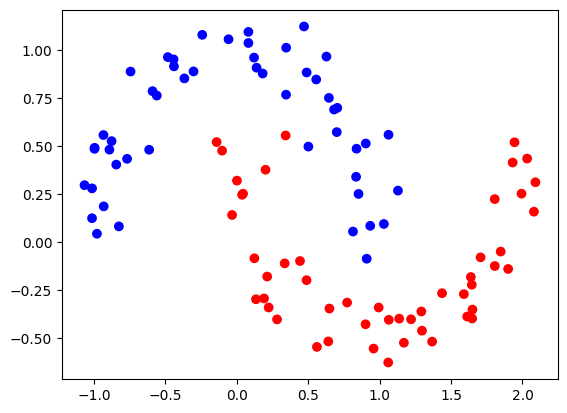

In [ ]:
X, Y = datasets.make_moons(100, noise=0.1)

color = ['blue' if k == 0 else 'red' for k in Y]

plt.scatter(X[:, 0], X[:, 1], c=color)
plt.savefig('duas_luas.svg')

## Funções que serão utilizadas

Adicionei as mesmas funções usadas no exemplo original (versão Keras, na função main):

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

## Run Neural Net
Mantive a função original, que roda apenas o forward pass e retorna a previsão, porém adicionei uma nova camada oculta, contendo dois neurônios, e modifiquei a função de ativação de alguns deles, deixando de usar apenas a sigmóide e passando a usar ReLU e tangente hiperbólica também. Essa função é usada para medir a acurácia antes e depois do treinamento.

In [ ]:
def run_neural_net(x, w0, b0, b1, w1, bo, wo):
    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = sigmoid(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = tanh(v1)

    ### nova camada oculta

    o01 = wo[0, 0] * y0
    o02 = wo[0, 1] * y1
    o03 = o01 + o02
    v2 = o03 + bo[0]
    y2 = relu(v2)

    o10 = wo[1, 0] * y0
    o11 = wo[1, 1] * y1
    o12 = o10 + o11
    v3 = o12 + bo[1]
    y3 = sigmoid(v3)

    ###

    s20 = y2 * w1[0]
    s21 = y3 * w1[1]
    s22 = s20 + s21
    v4 = s22 + b1[0]
    y4 = sigmoid(v4)

    return 1 if y4 > 0.5 else 0

## Neural net

Mesma modificação da que foi descrita acima: nova camada oculta, com dois neurônios, e uso das funções ReLU e tangente hiperbólica, além da sigmóide. Porém, essa função contém ambos o forward e o backward. Ela é usada durante o treinamento.

In [ ]:
def neural_net(x, d, w0, b0, b1, w1, wo, bo):
    # forward

    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = sigmoid(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = tanh(v1)

    ## Nova camada oculta

    o01 = wo[0, 0] * y0
    o02 = wo[0, 1] * y1
    o03 = o01 + o02
    v2 = o03 + bo[0]
    y2 = relu(v2)

    o10 = wo[1, 0] * y0
    o11 = wo[1, 1] * y1
    o12 = o10 + o11
    v3 = o12 + bo[1]
    y3 = sigmoid(v3)

    ##

    s20 = y2 * w1[0]
    s21 = y3 * w1[1]
    s22 = s20 + s21
    v4 = s22 + b1[0]
    y4 = sigmoid(v4)

    e = y4 - d
    L = 1/2 * (e ** 2)

    # backward
    grad_w0 = np.zeros(w0.shape)
    grad_wo = np.zeros(wo.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_bo = np.zeros(bo.shape)
    grad_b1 = np.zeros(b1.shape)

    grad_L = 1
    grad_e = grad_L * e

    grad_y4 = grad_e
    grad_v4 = grad_y4 * y4 * (1 - y4)
    grad_b1[0] = grad_v4

    grad_s22 = grad_v4
    grad_s21 = grad_s22
    grad_s20 = grad_s22

    grad_w1[1] = grad_s21 * y3
    grad_y3 = grad_s21 * w1[1]

    grad_w1[0] = grad_s20 * y2
    grad_y2 = grad_s20 * w1[0]

    grad_v2 = grad_y2 * (1 if v2 > 0 else 0)
    grad_v3 = grad_y3 * y3 * (1 - y3)

    grad_bo[0] = grad_v2
    grad_bo[1] = grad_v3

    grad_o03 = grad_v2
    grad_o02 = grad_o03
    grad_o01 = grad_o03

    grad_wo[0, 0] = grad_o01 * y0
    grad_wo[0, 1] = grad_o02 * y1

    grad_o12 = grad_v3
    grad_o11 = grad_o12
    grad_o10 = grad_o12

    grad_wo[1, 0] = grad_o10 * y0
    grad_wo[1, 1] = grad_o11 * y1

    grad_y0 = grad_o01 * wo[0, 0] + grad_o10 * wo[1, 0]
    grad_y1 = grad_o02 * wo[0, 1] + grad_o11 * wo[1, 1]

    grad_v0 = grad_y0 * y0 * (1 - y0)
    grad_v1 = grad_y1 * (1 - y1 ** 2)

    grad_b0[0] = grad_v0
    grad_b0[1] = grad_v1

    grad_s12 = grad_v1
    grad_s02 = grad_v0

    grad_s00 = grad_s02
    grad_s01 = grad_s02
    grad_s10 = grad_s12
    grad_s11 = grad_s12

    grad_w0[0, 0] = grad_s00 * x[0]
    grad_w0[0, 1] = grad_s01 * x[1]
    grad_w0[1, 0] = grad_s10 * x[0]
    grad_w0[1, 1] = grad_s11 * x[1]

    return grad_w0, grad_b0, grad_wo, grad_bo, grad_w1, grad_b1, L

## Main

In [ ]:
def main():
    # inicialização aleatória
    w0 = np.random.rand(2, 2)
    wo = np.random.rand(2, 2)
    w1 = np.random.rand(2)
    b0 = np.random.rand(2)
    bo = np.random.rand(2)
    b1 = np.random.rand(1)

    # taxa de aprendizado
    taxa = 0.1

    acc = 0
    for i in range(100):
        out = run_neural_net(X[i], w0, b0, b1, w1, bo, wo)
        if out == Y[i]:
            acc += 1
    print(acc, "acurácia antes do treinamento")

    #gradiente descendente
    for i in range(10000):
        loss = 0

        grad_w0 = np.zeros(w0.shape)
        grad_wo = np.zeros(wo.shape)
        grad_w1 = np.zeros(w1.shape)
        grad_b0 = np.zeros(b0.shape)
        grad_bo = np.zeros(bo.shape)
        grad_b1 = np.zeros(b1.shape)

        for k in range(100):
            g_w0, g_b0, g_wo, g_bo, g_w1, g_b1, L = neural_net(
                X[k], Y[k], w0, b0, b1, w1, wo, bo
            )

            grad_w0 += g_w0
            grad_wo += g_wo
            grad_w1 += g_w1
            grad_b0 += g_b0
            grad_bo += g_bo
            grad_b1 += g_b1
            loss += L

        w0 -= taxa * grad_w0
        wo -= taxa * grad_wo
        w1 -= taxa * grad_w1
        b0 -= taxa * grad_b0
        bo -= taxa * grad_bo
        b1 -= taxa * grad_b1

        if i % 1000 == 0:
            print(i, loss)

    # acurácia após o treinamento
    acc = 0
    for i in range(100):
        out = run_neural_net(X[i], w0, b0, b1, w1, bo, wo)
        if out == Y[i]:
            acc += 1
    print('acc', acc)

    model = Sequential()
    model.add(Dense(5, input_dim=2, activation='relu'))
    model.add(Dense(5, activation='tanh'))
    model.add(Dense(1, activation='sigmoid'))

    opt = SGD(learning_rate=taxa)
    model.compile(loss='mean_squared_error', optimizer=opt, metrics=['accuracy'])
    model.fit(X, Y, epochs=100, verbose=False, batch_size=5)

    acc = model.evaluate(X, Y)


main()

50 acurácia antes do treinamento
0 18.18756760423862
1000 4.8543880451847485
2000 4.666992458174392
3000 4.491811266793886
4000 4.429824882726602
5000 4.4077240610680715
6000 4.395841035167142
7000 4.388997880927884
8000 4.384525513539724
9000 4.381302575268968
acc 86
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9900 - loss: 0.0165  
